In [2]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

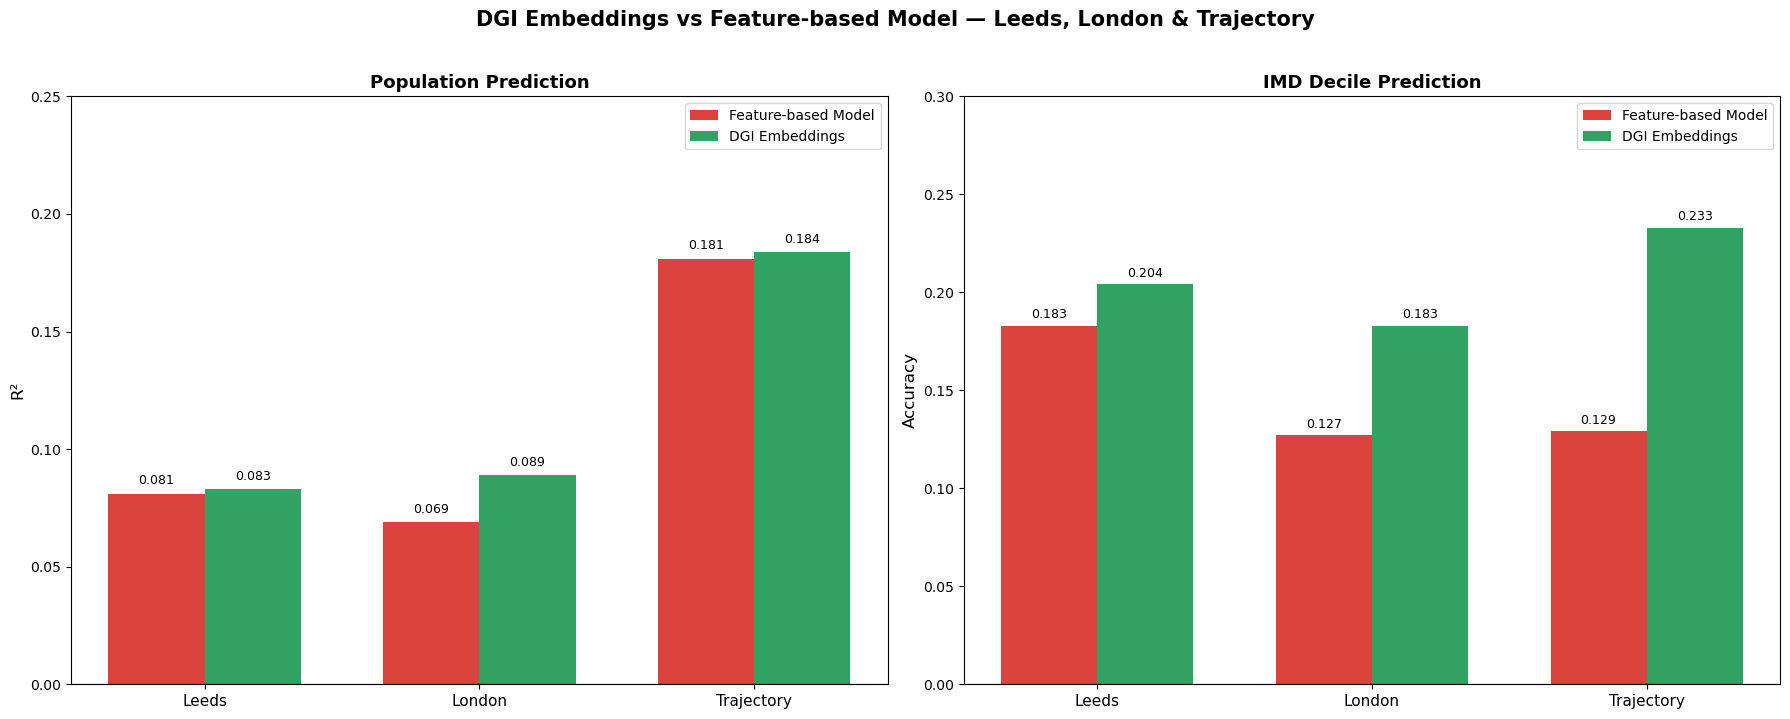

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data 
cities    = ['Leeds', 'London', 'Trajectory']

# Population R²
grav_pop  = [0.081, 0.069, 0.1809]
dgi_pop   = [0.083, 0.089, 0.1837]

# IMD Accuracy
grav_imd  = [0.183, 0.127, 0.129]
dgi_imd   = [0.204, 0.183, 0.233]

# Flow R²
dgi_flow  = [0.459341, 0.256139, 0.416951]
grav_flow = [0.1279, 0.0609, 0.4053]

# Colours 
grav_color = '#d73027'   # red — gravity model
dgi_color  = '#1a9850'   # green — DGI
flow_color = '#2166ac'   # blue — flow prediction

x     = np.arange(len(cities))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('DGI Embeddings vs Feature-based Model — Leeds, London & Trajectory',
             fontsize=15, fontweight='bold', y=1.02)

# Plot 1: Population Prediction 
bars1 = axes[0].bar(x - width/2, grav_pop, width,
                     label='Feature-based Model', color=grav_color, alpha=0.9)
bars2 = axes[0].bar(x + width/2, dgi_pop,  width,
                     label='DGI Embeddings',      color=dgi_color,  alpha=0.9)
axes[0].set_title('Population Prediction', fontweight='bold', fontsize=13)
axes[0].set_ylabel('R²', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(cities, fontsize=11)
axes[0].set_ylim(0, 0.25)
axes[0].legend(fontsize=10)
axes[0].axhline(0, color='black', linewidth=0.8)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9, color='black')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9, color='black')

# Plot 2: IMD Prediction
bars3 = axes[1].bar(x - width/2, grav_imd, width,
                     label='Feature-based Model', color=grav_color, alpha=0.9)
bars4 = axes[1].bar(x + width/2, dgi_imd,  width,
                     label='DGI Embeddings',      color=dgi_color,  alpha=0.9)
axes[1].set_title('IMD Decile Prediction', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cities, fontsize=11)
axes[1].set_ylim(0, 0.30)
axes[1].legend(fontsize=10)
axes[1].axhline(0, color='black', linewidth=0.8)
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9, color='black')
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


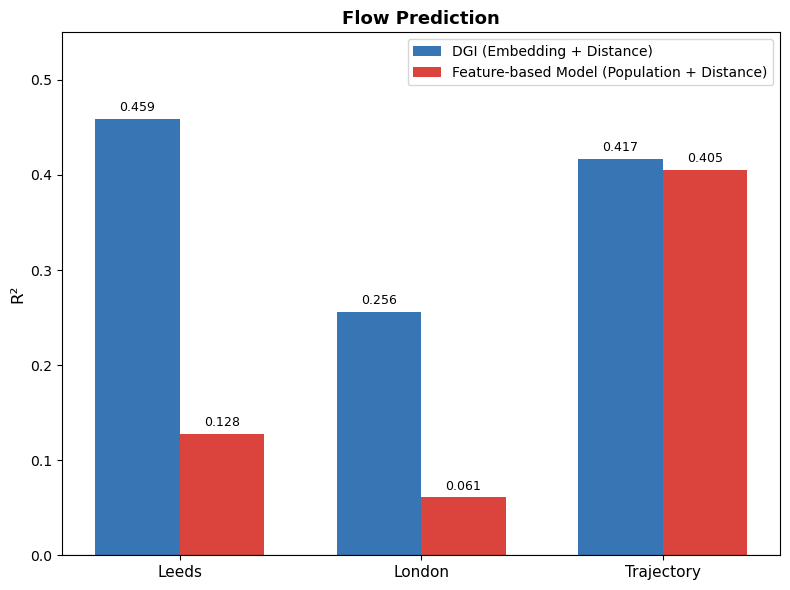

In [6]:
# Plot 3: Flow Prediction 
fig2, ax = plt.subplots(figsize=(8, 6))

flow_width = 0.35
x = np.arange(len(cities))  # make sure this exists

bars5 = ax.bar(x - flow_width/2, dgi_flow, flow_width,
               label='DGI (Embedding + Distance)', color=flow_color, alpha=0.9)

bars6 = ax.bar(x + flow_width/2, grav_flow, flow_width,
               label='Feature-based Model (Population + Distance)', color=grav_color, alpha=0.9)

ax.set_title('Flow Prediction',
             fontweight='bold', fontsize=13)
ax.set_ylabel('R²', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(cities, fontsize=11)
ax.set_ylim(0, 0.55)
ax.legend(fontsize=10)
ax.axhline(0, color='black', linewidth=0.8)

for bar in bars5:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

for bar in bars6:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()